In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from astroquery.vizier import Vizier
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from prospect.models.sedmodel import SedModel
from prospect.utils.obsutils import fix_obs
from prospect.likelihood import lnlike_spec, lnlike_phot, write_log
from prospect.likelihood import chi_spec, chi_phot
import fsps
import sedpy
import prospect
import emcee
import dynesty
import bagpipes as pipes


# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

bands = {
    # HST - Using common filters for ACS and WFC3
    'HST_F218W': ('F218W', 2225.17, 'UVIS', 'MAST'),
    'HST_F225W': ('F225W', 2371.15, 'UVIS', 'MAST'),
    'HST_F275W': ('F275W', 2709.29, 'UVIS', 'MAST'),
    'HST_F435W': ('F435W', 4329.85, 'ACS', 'MAST'),
    'HST_F606W': ('F606W', 5921.1, 'ACS', 'MAST'),
    'HST_F814W': ('F814W', 8057.2, 'ACS', 'MAST'),
    'HST_F125W': ('F125W', 12486.07, 'IR', 'MAST'),
    'HST_F160W': ('F160W', 15369.1, 'IR', 'MAST'),
    # Spitzer - Using channel names for IRAC and MIPS
    'Spitzer_I1_3.6': ('1', 36000., 'IRAC', 'Spitzer'),
    'Spitzer_I2_4.5': ('2', 45000., 'IRAC', 'Spitzer'),
    'Spitzer_I4_8.0': ('4', 80000., 'IRAC', 'Spitzer'),
    'Spitzer_M1_24': ('1', 240000., 'MIPS', 'Spitzer'),
}

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

peas = ascii.read('photometry_results.csv')

Bagpipes: Latex turned off in rcParams, plots may look strange.


In [2]:
grapes = tab[(tab['halpha_flux']>0)&(tab['oiii5007_ew']>100)]
grapes.sort('oiii5007_flux')
grapes[-2]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d04m12pt825s-44d21m10pt642s,38.070229166666664,-44.35295611111111,0.40292640529351553,66.73403958150307,0,0,0,8.969458542722732,0.0071141320617926825,8.150940159413311,0.0002622770955946467,8.162632124545151,0.2310792637281556,52.167125686054774,11.366223970474508,0.282,rxj0232m44,22567.1412073046,354.6168687556022,128.08897740369298,5.497713979981577,5006.834015829306,1.9980823399660776,47.58586696794032,6909.889981192684,933.7871419981336,19.408720732766298,7.277460935748094,4958.849131583009,1.7838306402540278,42.122918614158394,9815.98386042128,333.47237723449535,31.03228480758622,5.3098464551879445,3726.2293091856905,2.2526145560741524,73.15631758124707,11807.609335391948,374.7664395449063,37.404139444223546,5.967367573421555,3729.12559

In [3]:
# fig, ax = pf.create_plot()
# axes = [ax]
candidate = grapes[-2]
cluster = candidate['name']
print(cluster)
loc = '../../../cubes/'+cluster+'_COMBINED_CUBE_MED_FINAL.fits'
with fits.open(loc) as hdul:
    cx,cy = (hdul[1].header['CRVAL1'],hdul[1].header['CRVAL2'])
    cent = SkyCoord(cx,cy, unit = u.deg)

galloc = SkyCoord(candidate['ra'], candidate['dec'], unit=u.deg)
cube_ift = ift.museCube(loc, cent.ra.deg,cent.dec.deg)
cluster = Cube(loc)
subcube = cluster.subcube((galloc.dec.deg,galloc.ra.deg), size=3)
linefits = cube_ift.pick_target(galloc,candidate['z'],0.7,plot=False)

spectrum_o = cube_ift.spectra.get(list(cube_ift.spectra.keys())[0])
rest_spectrum = cube_ift.rest_spectra.get(list(cube_ift.rest_spectra.keys())[0])

freq = np.linspace(rest_spectrum.get_start(), rest_spectrum.get_end(), rest_spectrum.shape[0])
redshift = cube_ift.ex_table['z'][0]
d_lum = cosmo.luminosity_distance(redshift).to(u.Mpc).value 

wave_rest = rest_spectrum.wave.coord()  # Angstroms
flux = rest_spectrum.data*1e-20            # erg/s/cm^2/Angstrom (check units)
flux_unc = np.sqrt(rest_spectrum.var*1e-20)   # Get std deviation from variance

c = speedoflight.to(u.AA / u.s).value

flux_nu = flux * (wave_rest**2 / c)
unc_nu = flux_unc * (wave_rest**2 / c)
flux_jy = flux_nu/1e-23
unc_jy = unc_nu/1e-23
mask = flux_jy>0

rxj0232m44


In [4]:
# plt.semilogx(wave_rest[mask],flux_jy[mask]*1000)
cand_phot = peas[peas['object_id']==candidate['object_id']]

filters_names = [stri[5:] for stri in list(cand_phot.keys()[3:])]
filters_cwav = np.array([bands.get(name)[1] for name in filters_names])
photometry = np.array(cand_phot[0][3:])
photometry[photometry == -999] = np.nan
# plt.scatter(filters_cwav,photometry/1e3)
vizier = Vizier()
query = vizier.query_region(galloc, radius=3*u.arcsecond)
des_table = query['II/357/des_dr1']

hst_filters = ['wfc3_uvis_f225w','wfc3_uvis_f275w','acs_wfc_f435w','acs_wfc_f606w','acs_wfc_f814w','wfc3_ir_f125w','wfc3_ir_f160w',]
hst_phot_ujy = photometry[1:-4]
spitzer_filters = ['spitzer_irac_ch'+n for n in ['1','2','4']]
spizter_phot_ujy = photometry[-4:-1]
des_filters =  ['decam_'+b for b in ['g','r','i','z','Y']]
des_phot_mag = np.array([des_table[b+'mag'].data for b in ['g','r','i','z','Y']]).squeeze(1)
des_phot_ujy = (3631*(10**(-0.4*des_phot_mag)))*1e6

In [5]:
def build_obs(**extras):
    obs = {}
    filternames = hst_filters + spitzer_filters + des_filters
    obs["filters"] = sedpy.observate.load_filters(filternames)
    obs["maggies"] = (np.concatenate([hst_phot_ujy,spizter_phot_ujy,des_phot_ujy])*1e-9)/3631
    obs["maggies_unc"] = obs["maggies"]/10
    obs["phot_mask"] = np.isfinite(obs['maggies'])
    obs["phot_wave"] = np.array([f.wave_effective for f in obs["filters"]])
    obs["wavelength"] = wave_rest
    obs["spectrum"] = flux_jy*1e-3/3631
    obs['unc'] = unc_jy/3631
    obs['mask'] = obs["spectrum"]>0
    obs = fix_obs(obs)
    return obs
run_params = {}
obs = build_obs(**run_params)

Obs Dictionary Keys:

dict_keys(['filters', 'maggies', 'maggies_unc', 'phot_mask', 'phot_wave', 'wavelength', 'spectrum', 'unc', 'mask', 'filternames', 'logify_spectrum', 'ndof'])

--------
Filter objects:

[<class 'sedpy.observate.Filter'>(wfc3_uvis_f225w), <class 'sedpy.observate.Filter'>(wfc3_uvis_f275w), <class 'sedpy.observate.Filter'>(acs_wfc_f435w), <class 'sedpy.observate.Filter'>(acs_wfc_f606w), <class 'sedpy.observate.Filter'>(acs_wfc_f814w), <class 'sedpy.observate.Filter'>(wfc3_ir_f125w), <class 'sedpy.observate.Filter'>(wfc3_ir_f160w), <class 'sedpy.observate.Filter'>(spitzer_irac_ch1), <class 'sedpy.observate.Filter'>(spitzer_irac_ch2), <class 'sedpy.observate.Filter'>(spitzer_irac_ch4), <class 'sedpy.observate.Filter'>(decam_g), <class 'sedpy.observate.Filter'>(decam_r), <class 'sedpy.observate.Filter'>(decam_i), <class 'sedpy.observate.Filter'>(decam_z), <class 'sedpy.observate.Filter'>(decam_Y)]


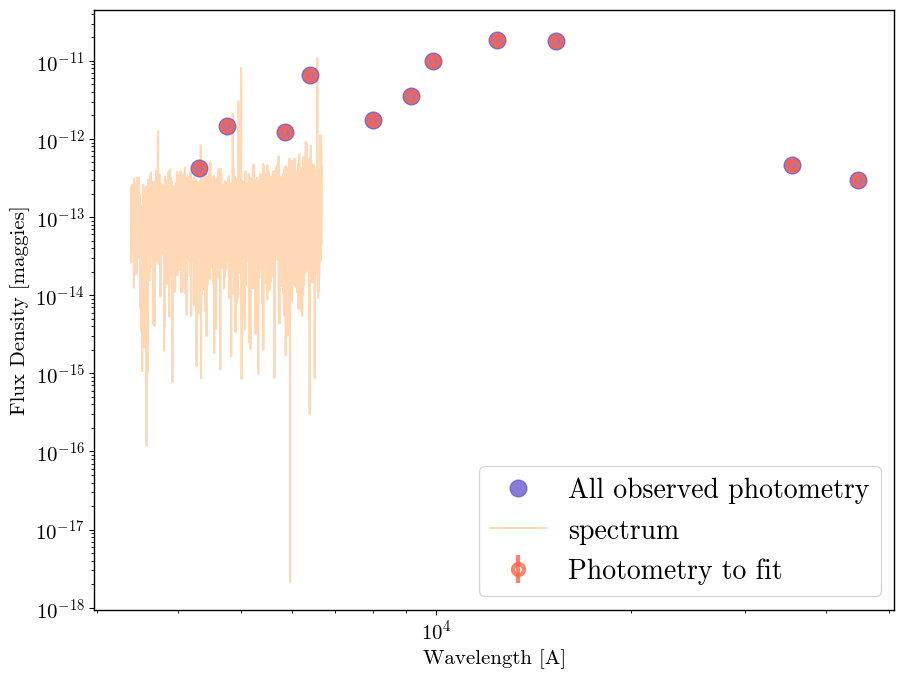

In [6]:
# Look at the contents of the obs dictionary
print("Obs Dictionary Keys:\n\n{}\n".format(obs.keys()))
print("--------\nFilter objects:\n")
print(obs["filters"])

# --- Plot the Data ----
# This is why we stored these...
wphot = obs["phot_wave"]

# establish bounds
xmin, xmax = np.min(wphot)*0.8, np.max(wphot)/0.8
ymin, ymax = obs["maggies"].min()*0.8, obs["maggies"].max()/0.4

fig,ax = pf.create_plot((8,6))


# plot all the data
ax.plot(wphot, obs['maggies'],
     label='All observed photometry',
     marker='o', markersize=12, alpha=0.8, ls='', lw=3,
     color='slateblue')

# overplot only the data we intend to fit
mask = obs["phot_mask"]
ax.errorbar(wphot[mask], obs['maggies'][mask], 
         yerr=obs['maggies_unc'][mask], 
         label='Photometry to fit',
         marker='o', markersize=8, alpha=0.8, ls='', lw=3,
         ecolor='tomato', markerfacecolor='none', markeredgecolor='tomato', 
         markeredgewidth=3)

mask2 = obs['mask']
ax.plot(obs['wavelength'][mask2],obs['spectrum'][mask2],label='spectrum', alpha=0.3,zorder=-10)

# plot Filters
for f in obs['filters']:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
# ax.set_xlim([xmin, xmax])
# ax.set_ylim([ymin, ymax])
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc='best', fontsize=20)

In [7]:
mass_param = {"name": "mass",
              "N": 1,
              "isfree": True,
              "init": 1e8,
              "prior": priors.LogUniform(mini=1e6, maxi=1e12),
              "init_disp": 1e6, 
              "disp_floor": 1e6, 
              "units": "solar masses formed",
              }

In [8]:
def build_model(fixed_metallicity=None, add_duste=False, 
                **extras):

    model_params = TemplateLibrary["parametric_sfh"]
    model_params["lumdist"] = {"N": 1, "isfree": False, "init": d_lum, "units":"Mpc"}
    
    model_params["zred"]["init"] = redshift
    model_params["dust2"]["init"] = 0.05
    model_params["logzsol"]["init"] = -0.5
    model_params["tage"]["init"] = 13.
    model_params["mass"]["init"] = 1e8
    
    model_params["dust2"]["prior"] = priors.TopHat(mini=0.0, maxi=2.0)
    model_params["tau"]["prior"] = priors.LogUniform(mini=1e-1, maxi=1e2)
    model_params["mass"]["prior"] = priors.LogUniform(mini=1e6, maxi=1e10)

    model_params["mass"]["disp_floor"] = 1e6
    model_params["tau"]["disp_floor"] = 1.0
    model_params["tage"]["disp_floor"] = 1.0
    
    if fixed_metallicity is not None:
        model_params["logzsol"]["isfree"] = False
        model_params["logzsol"]['init'] = fixed_metallicity 

    model_params["zred"]['isfree'] = False

    if add_duste:
        model_params.update(TemplateLibrary["dust_emission"])
        
    model = SedModel(model_params)

    return model

run_params["fixed_metallicity"] = None
run_params["add_duste"] = True
model = build_model(**run_params)
print(model)

:::::::
<class 'prospect.models.sedmodel.SedModel'>

Free Parameters: (name: prior) 
-----------
  mass: <class 'prospect.models.priors.LogUniform'>(mini=1000000.0,maxi=10000000000.0)
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-2,maxi=0.19)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=2.0)
  tage: <class 'prospect.models.priors.TopHat'>(mini=0.001,maxi=13.8)
  tau: <class 'prospect.models.priors.LogUniform'>(mini=0.1,maxi=100.0)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.40292641] 
  sfh: [4] 
  imf_type: [2] 
  dust_type: [0] 
  lumdist: [2259.49593322] 
  add_dust_emission: [ True] 
  duste_umin: [1.] 
  duste_qpah: [4.] 
  duste_gamma: [0.001] 


In [9]:
def build_sps(zcontinuous=1, **extras):
    sps = CSPSpecBasis(zcontinuous=zcontinuous)
    return sps
run_params["zcontinuous"] = 1
sps = build_sps(**run_params)

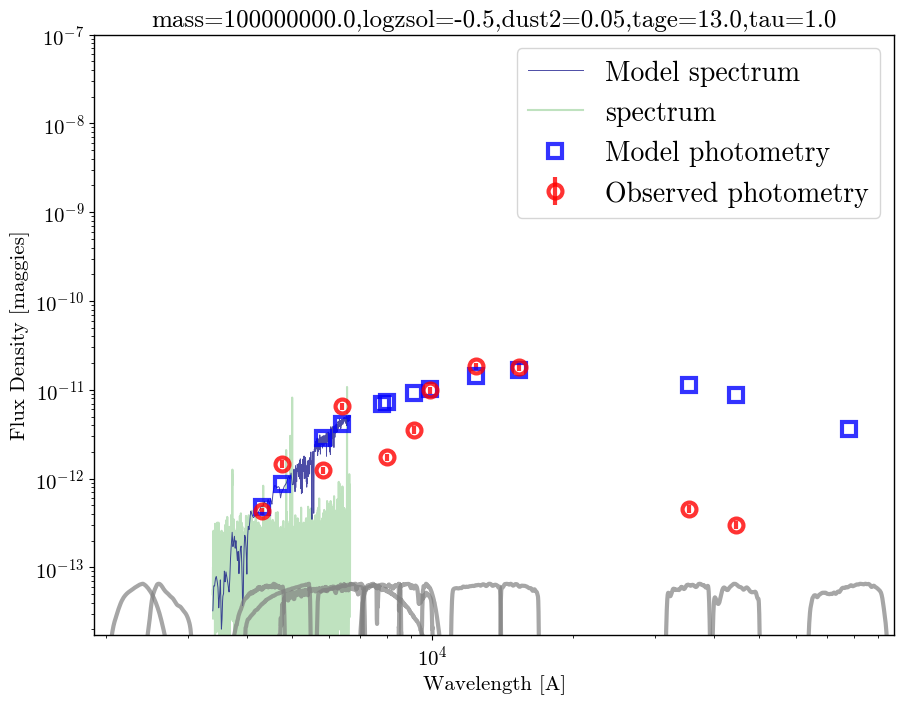

In [10]:
# Generate the model SED at the initial value of theta
theta = model.theta.copy()
initial_spec, initial_phot, initial_mfrac = model.sed(theta, obs=obs, sps=sps)
title_text = ','.join(["{}={}".format(p, model.params[p][0]) 
                       for p in model.free_params])

a = 1.0 + model.params.get('zred', 0.0) # cosmological redshifting
# photometric effective wavelengths
wphot = obs["phot_wave"]
# spectroscopic wavelengths
if obs["wavelength"] is None:
    # *restframe* spectral wavelengths, since obs["wavelength"] is None
    wspec = sps.wavelengths
    wspec *= a #redshift them
else:
    wspec = obs["wavelength"]

# establish bounds
xmin, xmax = np.min(wphot)*0.8, np.max(wphot)/0.8
temp = np.interp(np.linspace(xmin,xmax,10000), wspec, initial_spec)
ymin, ymax = temp.min()*0.8, temp.max()/0.4

fig, ax = pf.create_plot((8,6))

# plot model + data
ax.loglog(wspec, initial_spec, label='Model spectrum', 
       lw=0.7, color='navy', alpha=0.7)
ax.errorbar(wphot, initial_phot, label='Model photometry', 
         marker='s',markersize=10, alpha=0.8, ls='', lw=3,
         markerfacecolor='none', markeredgecolor='blue', 
         markeredgewidth=3)
ax.errorbar(wphot, obs['maggies'], yerr=obs['maggies_unc'], 
         label='Observed photometry',
         marker='o', markersize=10, alpha=0.8, ls='', lw=3,
         ecolor='red', markerfacecolor='none', markeredgecolor='red', 
         markeredgewidth=3)
ax.set_title(title_text)

mask2 = obs['mask']
ax.plot(obs['wavelength'][mask2],obs['spectrum'][mask2],label='spectrum', alpha=0.3,zorder=-10)

# plot Filters
for f in obs['filters']:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, 1e-7])
ax.legend(loc='best', fontsize=20)


In [11]:
verbose = False
def lnprobfn(theta, model=None, obs=None, sps=None, 
             nested=False, verbose=verbose):
    lnp_prior = model.prior_product(theta, nested=nested)
    if not np.isfinite(lnp_prior):
        return -np.inf
        
    # Generate "mean" model
    spec, phot, mfrac = model.mean_model(theta, obs, sps=sps)
 
    # Calculate likelihoods
    lnp_spec = lnlike_spec(spec, obs=obs)
    lnp_phot = lnlike_phot(phot, obs=obs)

    return lnp_prior + lnp_phot + lnp_spec

run_params["verbose"] = verbose

def chivecfn(theta):
    lnp_prior = model.prior_product(theta)
    if not np.isfinite(lnp_prior):
        return np.zeros(model.ndim) - np.inf
    try:
        spec, phot, x = model.mean_model(theta, obs, sps=sps)
    except(ValueError):
        return np.zeros(model.ndim) - np.inf
    chispec = chi_spec(spec, obs)
    chiphot = chi_phot(phot, obs)
    return np.concatenate([chispec, chiphot])

In [12]:
obs = build_obs(**run_params)
sps = build_sps(**run_params)
model = build_model(**run_params)

# run_params["dynesty"] = False
# run_params["emcee"] = False
# run_params["optimize"] = True
# run_params["min_method"] = 'lm'
# run_params["nmin"] = 2

run_params["dynesty"] = True
run_params["optmization"] = False
run_params["emcee"] = False
run_params["nested_method"] = "rwalk"
run_params["nlive_init"] = 400
run_params["nlive_batch"] = 200
run_params["nested_dlogz_init"] = 0.05
run_params["nested_posterior_thresh"] = 0.05
run_params["nested_maxcall"] = int(1e7)

output = fitting.fit_model(obs, model, sps, lnprobfn=fitting.lnprobfn, **run_params)

iter: 45 | batch: 0 | nc: 1 | ncall: 56 | eff(%): 28.846 | logz: -8597601.149 +/-  0.239 | dlogz:    inf >  0.050        

17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


iter: 77 | batch: 0 | nc: 2 | ncall: 116 | eff(%): 35.648 | logz: -220671.329 +/-  0.246 | dlogz: 231620.732 >  0.050    

17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


iter: 101 | batch: 0 | nc: 3 | ncall: 173 | eff(%): 36.996 | logz: -37979.992 +/-  0.250 | dlogz: 38344.836 >  0.050     

...

iter: 2455 | batch: 0 | nc: 8 | ncall: 12758 | eff(%): 19.093 | logz: -2353.432 +/-  0.425 | dlogz:  0.051 >  0.050    

17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


iter: 2556 | batch: 0 | nc: 1 | ncall: 12872 | eff(%): 19.857 | logz: -2353.401 +/-  0.429 | dlogz:  0.000 >  0.050     

17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


AttributeError: 'DynamicNestedSampler' object has no attribute 'M'

In [ ]:
print(model.theta)
(results, topt) = output["optimization"]
# Find which of the minimizations gave the best result, 
# and use the parameter vector for that minimization
ind_best = np.argmin([r.cost for r in results])
print(ind_best)
theta_best = results[ind_best].x.copy()
print(theta_best)

# generate model
prediction = model.mean_model(theta_best, obs=obs, sps=sps)
pspec, pphot, pfrac = prediction

fig, ax = pf.create_plot((8,6))

# plot Data, best fit model, and old models
ax.loglog(wspec, initial_spec, label='Old model spectrum',
       lw=0.7, color='gray', alpha=0.5)
ax.errorbar(wphot, initial_phot, label='Old model Photometry', 
         marker='s', markersize=10, alpha=0.6, ls='', lw=3, 
         markerfacecolor='none', markeredgecolor='gray', 
         markeredgewidth=3)
ax.loglog(wspec, pspec, label='Model spectrum', 
       lw=0.7, color='slateblue', alpha=0.7)
ax.errorbar(wphot, pphot, label='Model photometry', 
         marker='s', markersize=10, alpha=0.8, ls='', lw=3,
         markerfacecolor='none', markeredgecolor='slateblue', 
         markeredgewidth=3)
ax.errorbar(wphot, obs['maggies'], yerr=obs['maggies_unc'],
         label='Observed photometry', 
         marker='o', markersize=10, alpha=0.8, ls='', lw=3, 
         ecolor='tomato', markerfacecolor='none', markeredgecolor='tomato', 
         markeredgewidth=3)

# plot filter transmission curves
for f in obs['filters']:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# Prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, 1e-7])
ax.legend(loc='best', fontsize=20)

[ 1.01163734e+09 -1.67264838e+00  1.62939790e+00  1.37966513e+01
  1.08098869e-01]


TypeError: 'NoneType' object is not iterable

In [ ]:
help(dynesty)

Help on package dynesty:

NAME
    dynesty

DESCRIPTION
    dynesty is nested sampling package.
    The main functionality of dynesty is performed by the
    dynesty.NestedSampler and dynesty.DynamicNestedSampler
    classes

PACKAGE CONTENTS
    bounding
    dynamicsampler
    dynesty
    internal_samplers
    plotting
    pool
    results
    sampler
    utils

VERSION
    3.0.0

FILE
    /Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/dynesty/__init__.py


